<a href="https://colab.research.google.com/github/keyedeye42-ops/Colab-to-Githhub/blob/main/Colab_to_Github_Data_mining_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load your specific file
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving Daily-1Raw_Daily_Imputed.csv to Daily-1Raw_Daily_Imputed (1).csv


,Date,USD,EUR,JPY,GBP,CAD,CHF,INR,CNY,TRY,SAR,IDR,AED,THB,VND,EGP,KRW,RUB,ZAR,AUD
0,12/29/1978,226,137.1,89668.53,110.7,910.95,865.79,37984.91,4549.32,2834.14,2768.15,7117547.34,2732.28,23463.63,12613005.94,6717.24,788332.07,28341.8,7030.64,946.87
1,1/1/1979,226,137.1,89668.53,110.7,910.95,865.79,37984.91,4549.32,2834.14,2768.15,7117547.34,2732.28,23463.63,12613005.94,6717.24,788332.07,28341.8,7030.64,946.87
2,1/2/1979,226.8,137.3,"43,164.90",111.5,263.7,359.6,"1,792.90",4549.32,2834.14,735.6,"138,160.50",851.3,"4,454.60",12613005.94,6717.24,"107,470.00",28341.8,194.6,193.6
3,1/3/1979,218.6,134,"43,717.90",108,264.4,365.9,"1,802.20",4549.32,2834.14,739.4,"138,877.00",855.7,"4,477.70",12613005.94,6717.24,"108,027.40",28341.8,192.2,193
4,1/4/1979,223.2,136.8,"43,674.90",110.7,264.1,366.4,"1,811.70",4549.32,2834.14,743.4,"139,616.30",860.3,"4,501.50",12613005.94,6717.24,"108,602.50",28341.8,193,194.6


In [6]:
# Clean numeric columns: Remove commas and convert to float
# We apply this to all columns except 'Date'
cols_to_fix = df.columns.drop('Date')
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

# Example Setup: Predict 'USD' using 'EUR', 'JPY', and 'GBP'
X = df[['EUR', 'JPY', 'GBP']]
y = df['USD']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple model
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

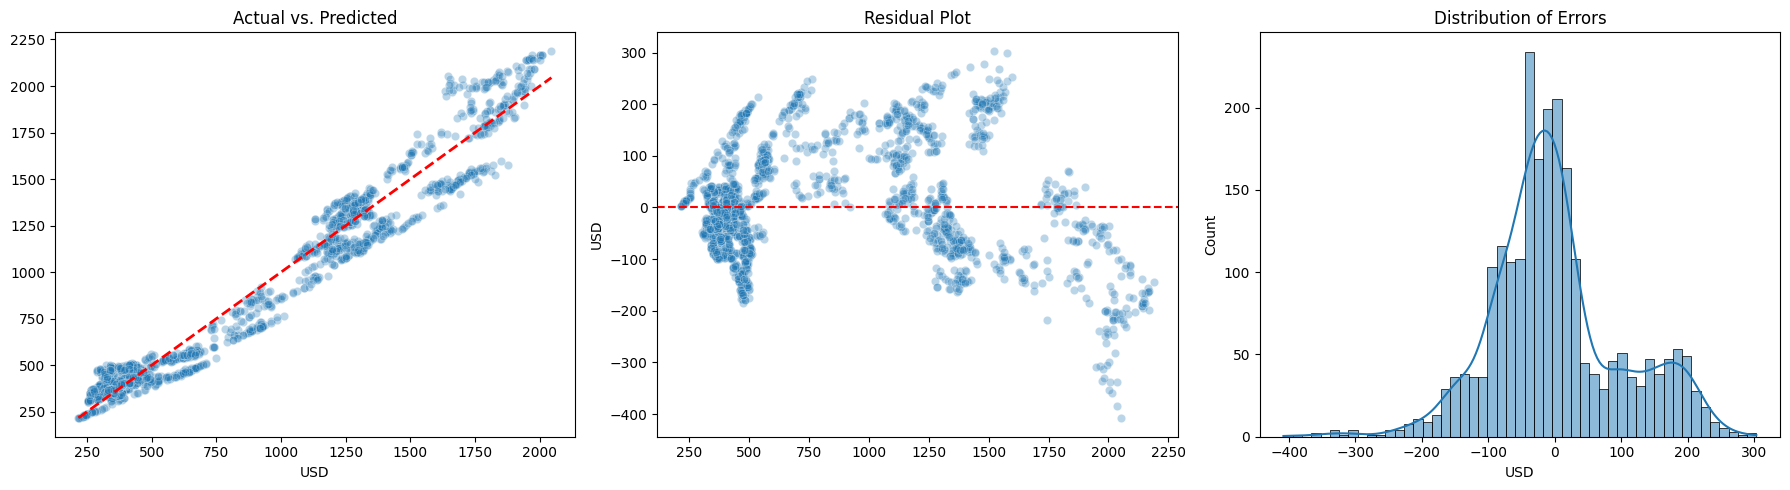

In [5]:
# Create a dashboard of 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted')

# Plot 2: Residual Plot
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Residual Plot')

# Plot 3: Error Distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Errors')

plt.tight_layout()
plt.show()